# **Data Cleaning & Reporting Automation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/Data Cleaning Dataset.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


**Check the dataset**

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Number of rows: 12575
Number of columns: 11


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


**Check column names**

In [ ]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


**Check data types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


**Check missing values**

In [ ]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


**Check duplicate rows**

In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


**Basic statistical summary**

In [ ]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


# **Data Quality Summary**

In [ ]:
quality_report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})

quality_report

,Column,Data Type,Missing Values,Missing %,Unique Values
Transaction ID,Transaction ID,object,0,0.00,12575
Customer ID,Customer ID,object,0,0.00,25
Category,Category,object,0,0.00,8
Item,Item,object,1213,9.65,200
Price Per Unit,Price Per Unit,float64,609,4.84,25
Quantity,Quantity,float64,604,4.80,10
Total Spent,Total Spent,float64,604,4.80,227
Payment Method,Payment Method,object,0,0.00,3
Location,Location,object,0,0.00,2
Transaction Date,Transaction Date,object,0,0.00,1114


In [ ]:
print("DATA QUALITY REPORT")
print("=" * 60)

display(quality_report)

DATA QUALITY REPORT


,Column,Data Type,Missing Values,Missing %,Unique Values
Transaction ID,Transaction ID,object,0,0.00,12575
Customer ID,Customer ID,object,0,0.00,25
Category,Category,object,0,0.00,8
Item,Item,object,1213,9.65,200
Price Per Unit,Price Per Unit,float64,609,4.84,25
Quantity,Quantity,float64,604,4.80,10
Total Spent,Total Spent,float64,604,4.80,227
Payment Method,Payment Method,object,0,0.00,3
Location,Location,object,0,0.00,2
Transaction Date,Transaction Date,object,0,0.00,1114


# Handle Missing **Values**

**Missing values**

In [ ]:
missing = df.isnull().sum()

print("Missing values before cleaning:")
print(missing)

Missing values before cleaning:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


**Fill missing values**

In [ ]:
df['Item'] = df['Item'].fillna('Unknown')

**Fill missing Quantity**

In [ ]:
df['Quantity'] = df['Quantity'].fillna(
    df['Quantity'].median()
)

**Fill missing Total Spent**

In [ ]:
df['Total Spent'] = df['Total Spent'].fillna(
    df['Total Spent'].median()
)

**Fill missing Discount Applied**

In [ ]:
df['Discount Applied'] = df['Discount Applied'].fillna('No')

**Checking again**

In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Transaction ID        0
Customer ID           0
Category              0
Item                  0
Price Per Unit      609
Quantity              0
Total Spent           0
Payment Method        0
Location              0
Transaction Date      0
Discount Applied      0
dtype: int64


# **Checking for duplicates**

In [ ]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 0


In [ ]:
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


# **Checking and Fix Inconsistent Data**

**Checking unique values**

In [ ]:
print("Unique values in Category:")
print(df['Category'].unique())

print("\nUnique values in Item:")
print(df['Item'].unique())

print("\nUnique values in Payment Method:")
print(df['Payment Method'].unique())

print("\nUnique values in Discount Applied:")
print(df['Discount Applied'].unique())

Unique values in Category:
['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']

Unique values in Item:
['Item_10_PAT' 'Item_17_MILK' 'Item_12_BUT' 'Item_16_BEV' 'Item_6_FOOD'
 'Unknown' 'Item_1_FOOD' 'Item_16_FUR' 'Item_22_BUT' 'Item_3_BUT'
 'Item_2_FOOD' 'Item_24_PAT' 'Item_16_MILK' 'Item_17_PAT' 'Item_13_EHE'
 'Item_7_BEV' 'Item_4_EHE' 'Item_10_FOOD' 'Item_14_FUR' 'Item_20_BUT'
 'Item_25_FUR' 'Item_14_FOOD' 'Item_22_PAT' 'Item_11_FOOD' 'Item_6_PAT'
 'Item_21_EHE' 'Item_25_BEV' 'Item_23_FOOD' 'Item_10_FUR' 'Item_11_BEV'
 'Item_23_BUT' 'Item_22_BEV' 'Item_10_EHE' 'Item_24_BUT' 'Item_8_BEV'
 'Item_3_FOOD' 'Item_12_FOOD' 'Item_16_CEA' 'Item_11_PAT' 'Item_16_BUT'
 'Item_5_CEA' 'Item_19_MILK' 'Item_23_FUR' 'Item_7_FUR' 'Item_15_CEA'
 'Item_6_MILK' 'Item_24_CEA' 'Item_22_CEA' 'Item_22_FOOD' 'Item_2_BUT'
 'Item_14_PAT' 'Item_12_PAT' 'Item_18_FOOD' 'Item_1_PAT' 'Item_4_BEV'
 'Item_22_FUR' 'Item_7_PAT' '

**Checking numerical columns**

In [ ]:
print("Data types:")
print(df.dtypes)

Data types:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object


**Convert numerical columns**

In [ ]:
numeric_columns = ['Quantity', 'Price Per Unit', 'Total Spent']

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

print(df[numeric_columns].dtypes)

Quantity          float64
Price Per Unit    float64
Total Spent       float64
dtype: object


**Checking for invalid numerical values**

In [ ]:
print("Negative Quantity values:", (df['Quantity'] < 0).sum())
print("Negative Price values:", (df['Price Per Unit'] < 0).sum())
print("Negative Total Spent values:", (df['Total Spent'] < 0).sum())

Negative Quantity values: 0
Negative Price values: 0
Negative Total Spent values: 0


**Checking whether Total Spent is consistent**

In [ ]:
df['Calculated Total'] = df['Quantity'] * df['Price Per Unit']

df['Difference'] = (
    df['Total Spent'] - df['Calculated Total']
).abs()

print("Number of records with inconsistent Total Spent:",
      (df['Difference'] > 0.01).sum())

Number of records with inconsistent Total Spent: 604


**Fix inconsistent Total Spent**

In [ ]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

In [ ]:
df.drop(columns=['Calculated Total', 'Difference'], inplace=True)

**Final check**

In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset shape:", df.shape)

df.head()

Missing values:
Transaction ID        0
Customer ID           0
Category              0
Item                  0
Price Per Unit      609
Quantity              0
Total Spent         609
Payment Method        0
Location              0
Transaction Date      0
Discount Applied      0
dtype: int64

Duplicate rows: 0

Dataset shape: (12575, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,No
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


# **Save Cleaned Dataset & Generate Report**

**Save the cleaned dataset**

In [ ]:
cleaned_file = '/content/cleaned_retail_sales.csv'

df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved successfully!")
print(cleaned_file)

Cleaned dataset saved successfully!
/content/cleaned_retail_sales.csv


**Create automated data-quality report**

In [ ]:
report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

report

,Column,Data Type,Missing Values,Unique Values
Transaction ID,Transaction ID,object,0,12575
Customer ID,Customer ID,object,0,25
Category,Category,object,0,8
Item,Item,object,0,201
Price Per Unit,Price Per Unit,float64,609,25
Quantity,Quantity,float64,0,10
Total Spent,Total Spent,float64,609,227
Payment Method,Payment Method,object,0,3
Location,Location,object,0,2
Transaction Date,Transaction Date,object,0,1114


**Add data-quality status**

In [ ]:
report['Status'] = report['Missing Values'].apply(
    lambda x: 'Good' if x == 0 else 'Needs Cleaning'
)

report

,Column,Data Type,Missing Values,Unique Values,Status
Transaction ID,Transaction ID,object,0,12575,Good
Customer ID,Customer ID,object,0,25,Good
Category,Category,object,0,8,Good
Item,Item,object,0,201,Good
Price Per Unit,Price Per Unit,float64,609,25,Needs Cleaning
Quantity,Quantity,float64,0,10,Good
Total Spent,Total Spent,float64,609,227,Needs Cleaning
Payment Method,Payment Method,object,0,3,Good
Location,Location,object,0,2,Good
Transaction Date,Transaction Date,object,0,1114,Good


**Save the report**

In [ ]:
report_file = '/content/data_quality_report.csv'

report.to_csv(report_file, index=False)

print("Data quality report saved successfully!")
print(report_file)

Data quality report saved successfully!
/content/data_quality_report.csv


# **Generate a Sales Summary**

**Overall sales summary**

In [ ]:
total_sales = df['Total Spent'].sum()
total_transactions = df['Transaction ID'].nunique()
average_transaction = df['Total Spent'].mean()

print("SALES SUMMARY")
print("=" * 40)
print("Total Sales:", round(total_sales, 2))
print("Total Transactions:", total_transactions)
print("Average Transaction:", round(average_transaction, 2))

SALES SUMMARY
Total Sales: 1558294.5
Total Transactions: 12575
Average Transaction: 130.23


**Sales by category**

In [ ]:
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values(
    ascending=False
)

print("Sales by Category:")
print(category_sales)

Sales by Category:
Category
Butchers                              207461.0
Electric household essentials         203925.5
Beverages                             197785.5
Furniture                             196607.0
Food                                  195058.0
Computers and electric accessories    192233.5
Patisserie                            184696.5
Milk Products                         180527.5
Name: Total Spent, dtype: float64


**Visualize sales by category**

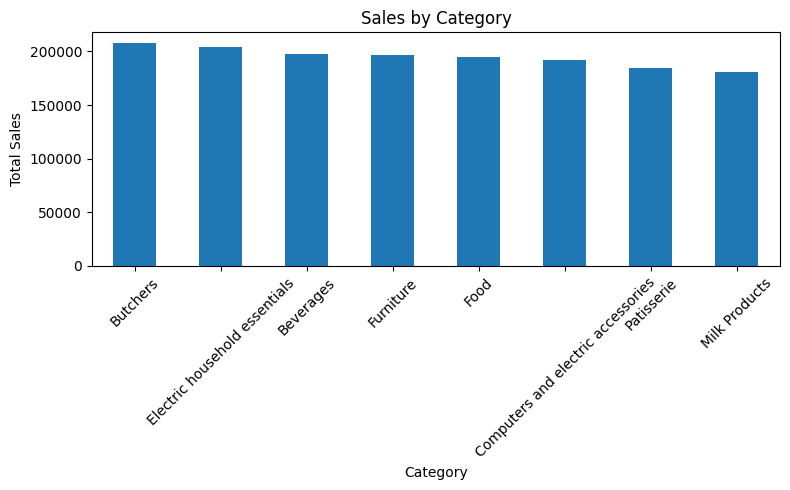

In [ ]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Payment method summary**

In [ ]:
payment_summary = df.groupby('Payment Method')['Total Spent'].sum().sort_values(
    ascending=False
)

print("Sales by Payment Method:")
print(payment_summary)

Sales by Payment Method:
Payment Method
Cash              543241.0
Credit Card       508528.0
Digital Wallet    506525.5
Name: Total Spent, dtype: float64


**Payment method visualization**

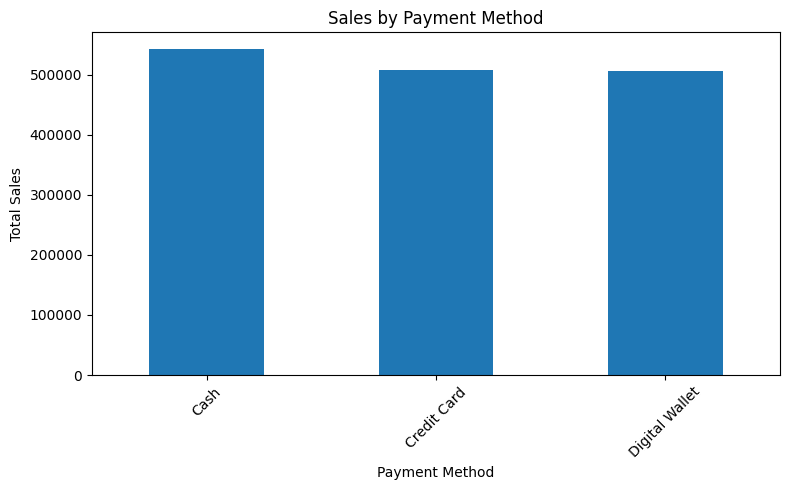

In [ ]:
plt.figure(figsize=(8, 5))

payment_summary.plot(kind='bar')

plt.title('Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Create Key Business Insights**

**Top-selling category**

In [ ]:
top_category = category_sales.idxmax()
top_category_sales = category_sales.max()

print("Top Selling Category:", top_category)
print("Sales:", round(top_category_sales, 2))

Top Selling Category: Butchers
Sales: 207461.0


**Most used payment method**

In [ ]:
top_payment = payment_summary.idxmax()

print("Most Used Payment Method:", top_payment)

Most Used Payment Method: Cash


**Create a summary table**

In [ ]:
summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Transactions',
        'Average Transaction',
        'Top Selling Category',
        'Top Payment Method'
    ],
    'Value': [
        round(total_sales, 2),
        total_transactions,
        round(average_transaction, 2),
        top_category,
        top_payment
    ]
})

summary

,Metric,Value
0,Total Sales,1558294.5
1,Total Transactions,12575
2,Average Transaction,130.23
3,Top Selling Category,Butchers
4,Top Payment Method,Cash


# **Create Final Automated Report**

In [ ]:
final_report = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Transactions',
        'Average Transaction',
        'Top Selling Category',
        'Top Category Sales',
        'Most Used Payment Method'
    ],
    'Value': [
        round(total_sales, 2),
        total_transactions,
        round(average_transaction, 2),
        top_category,
        round(top_category_sales, 2),
        top_payment
    ]
})

final_report.to_csv(
    '/content/final_sales_report.csv',
    index=False
)

print("Final automated report created successfully!")

Final automated report created successfully!


# **Displaing the final report**

In [ ]:
display(final_report)

,Metric,Value
0,Total Sales,1558294.5
1,Total Transactions,12575
2,Average Transaction,130.23
3,Top Selling Category,Butchers
4,Top Category Sales,207461.0
5,Most Used Payment Method,Cash


# **Create One More Useful Visualization**

**Top 10 Items by Sales chart**

In [ ]:
item_sales = df.groupby('Item')['Total Spent'].sum().sort_values(
    ascending=False
).head(10)

print("Top 10 Items by Sales:")
print(item_sales)

Top 10 Items by Sales:
Item
Unknown         85296.0
Item_25_FUR     25256.0
Item_25_EHE     23083.0
Item_25_BUT     21894.0
Item_24_FUR     21172.0
Item_25_FOOD    20541.0
Item_22_BUT     19710.0
Item_23_BUT     19114.0
Item_20_BUT     18860.5
Item_19_MILK    18848.0
Name: Total Spent, dtype: float64


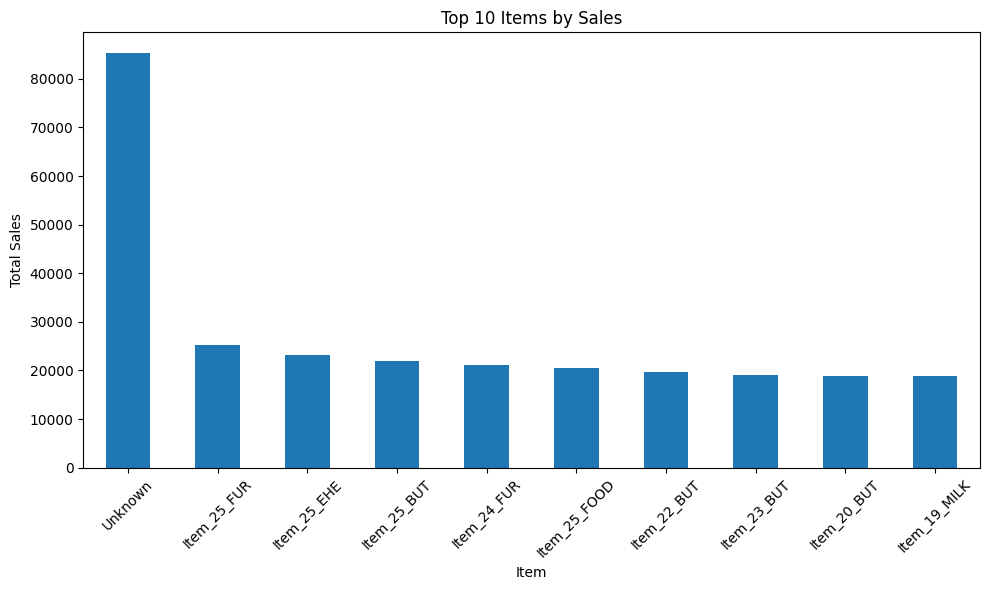

In [ ]:
plt.figure(figsize=(10, 6))

item_sales.plot(kind='bar')

plt.title('Top 10 Items by Sales')
plt.xlabel('Item')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Save the Chart**

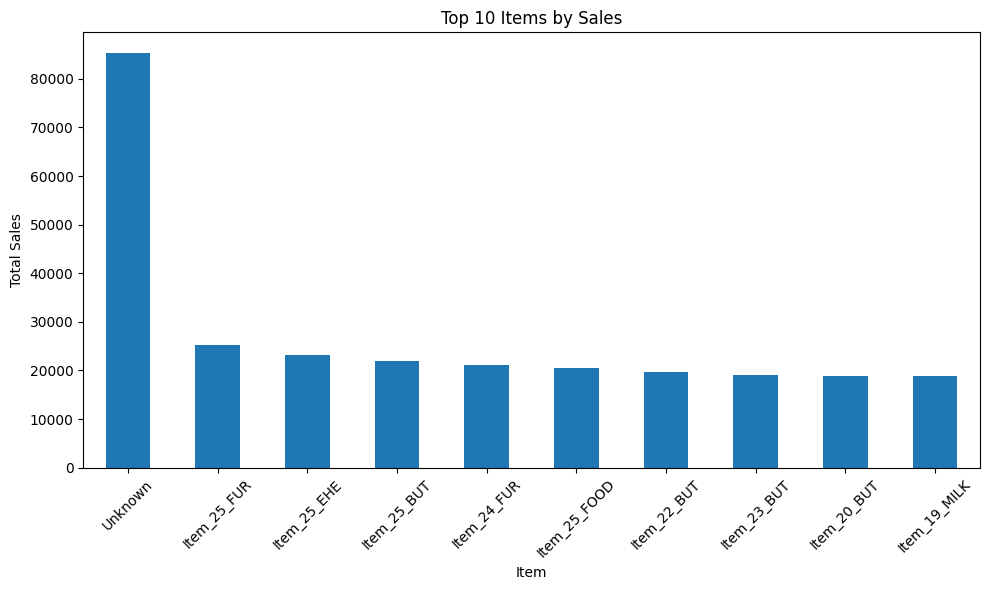

Chart saved successfully!


In [ ]:
plt.figure(figsize=(10, 6))

item_sales.plot(kind='bar')

plt.title('Top 10 Items by Sales')
plt.xlabel('Item')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('/content/top_10_items_sales.png', dpi=300, bbox_inches='tight')

plt.show()

print("Chart saved successfully!")

# **Checking the cleaned dataset**

In [ ]:
print("FINAL DATASET CHECK")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

FINAL DATASET CHECK
Rows: 12575
Columns: 11

Missing Values:
Transaction ID        0
Customer ID           0
Category              0
Item                  0
Price Per Unit      609
Quantity              0
Total Spent         609
Payment Method        0
Location              0
Transaction Date      0
Discount Applied      0
dtype: int64

Duplicate Rows: 0

Data Types:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object


**Checking the important files**

In [ ]:
import os

files = [
    '/content/cleaned_retail_sales.csv',
    '/content/data_quality_report.csv',
    '/content/final_sales_report.csv',
    '/content/top_10_items_sales.png'
]

print("PROJECT OUTPUT FILES")
print("=" * 50)

for file in files:
    if os.path.exists(file):
        print("✓", os.path.basename(file))
    else:
        print("✗ Missing:", os.path.basename(file))

PROJECT OUTPUT FILES
✓ cleaned_retail_sales.csv
✓ data_quality_report.csv
✓ final_sales_report.csv
✓ top_10_items_sales.png
